<a href="https://colab.research.google.com/github/kuzovkov/neural-university/blob/main/%D0%91%D0%B0%D0%B7%D0%BE%D0%B2%D1%8B%D0%B9_%D0%B1%D0%BB%D0%BE%D0%BA_%7C_%D0%91%D0%B8%D0%B1%D0%BB%D0%B8%D0%BE%D1%82%D0%B5%D0%BA%D0%B8_Pandas_%D0%B8_Matplotlib_%7C_%D0%94%D0%97_Ultra_Pro_%7C_%D0%A3%D0%98%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Задача 1

**Дано 4 графика:**

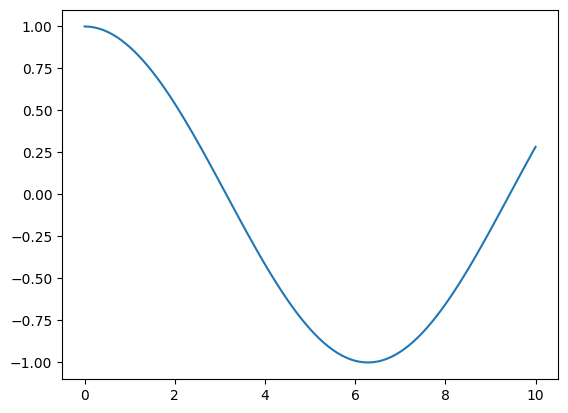

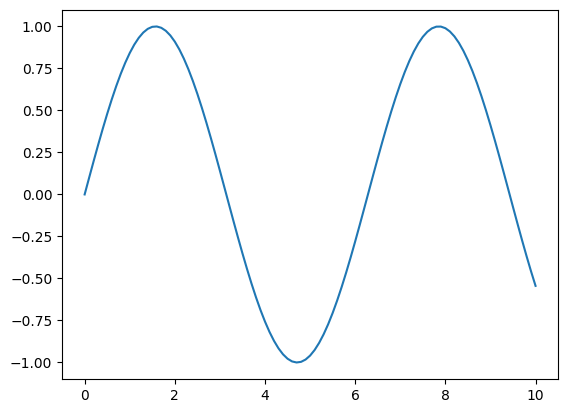

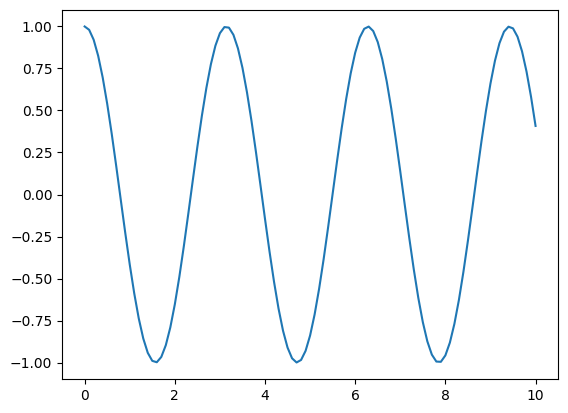

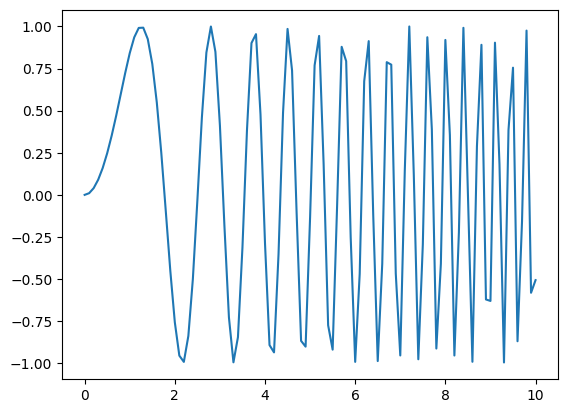

In [1]:
import matplotlib.pyplot as plt           # Импорт модуля pyplot
import numpy as np                        # Импорт библиотеки numpy
x = np.linspace(0, 10, 101)               # Генерация последовательности из 101 числа с шагом 0.1

plt.plot(x, np.cos(x / 2))
plt.show()

plt.plot(x, np.sin(x))
plt.show()

plt.plot(x, np.cos(x * 2))
plt.show()

plt.plot(x, np.sin(x ** 2))
plt.show()

**Приведите эти графики к следующему отображению:**

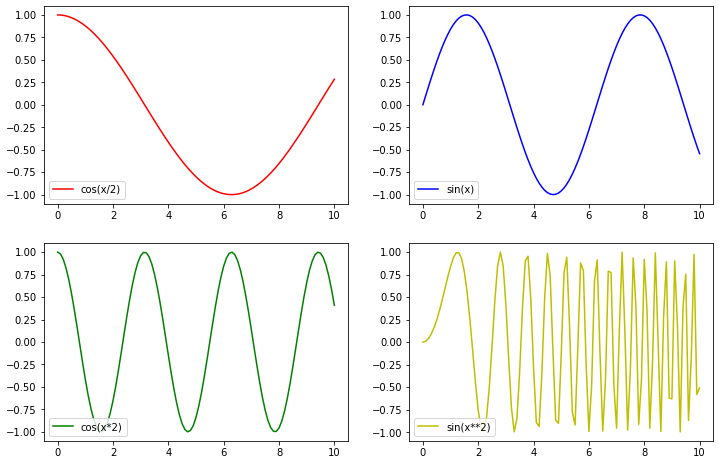

Обратите внимание:
- графики расположены по сетке
- каждый график подписан, а легенда находится слева снизу
- у графиков нет общих осей
- цвет графиков может быть произвольным

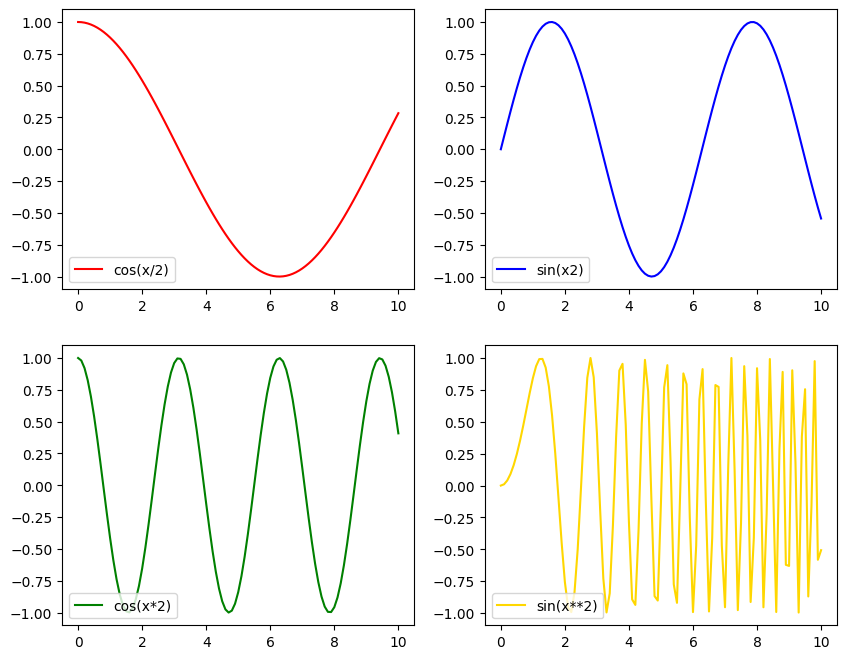

In [2]:
# Ваше решение
import matplotlib.pyplot as plt           # Импорт модуля pyplot
import numpy as np                        # Импорт библиотеки numpy
x = np.linspace(0, 10, 101)               # Генерация последовательности из 101 числа с шагом 0.1

plt.figure(1, figsize=(10, 8))
plt.subplot(221)
plt.plot(x, np.cos(x / 2), c='red', label='cos(x/2)')
plt.legend(loc='lower left')


plt.subplot(222)
plt.plot(x, np.sin(x), c='blue', label='sin(x2)')
plt.legend(loc='lower left')


plt.subplot(223)
plt.plot(x, np.cos(x * 2), c='green', label='cos(x*2)')
plt.legend(loc='lower left')


plt.subplot(224)
plt.plot(x, np.sin(x ** 2), c='gold', label='sin(x**2)')
plt.legend(loc='lower left')
plt.show()

### Задача 2

Загрузите базу данных - https://storage.yandexcloud.net/aiueducation/Content/base/l9/data.csv

---

При возникновении ошибки:
```
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa3 in position 28: invalid start byte
```
Укажите у метода `.read_csv()` параметр `encoding='cp1250'`

---

Столбец **InvoiceDate** преобразуйте в DataTime Index, а затем удалите его.

Затем проведите анализ данных:
- вычислите общее количество ячеек
- определите тип данных каждого столбца
- определите, есть ли пропуски

In [3]:
# Ваше решение
import gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l9/data.csv', None, quiet=True)

'data.csv'

In [4]:
import pandas as pd
df = pd.read_csv('data.csv', encoding='cp1250')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
df.index = pd.to_datetime(df.InvoiceDate)
df.drop('InvoiceDate', axis=1, inplace=True)
df.head()

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
InvoiceDate,,,,,,,
2010-12-01 08:26:00,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom
2010-12-01 08:26:00,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom
2010-12-01 08:26:00,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom
2010-12-01 08:26:00,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom
2010-12-01 08:26:00,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom


In [6]:
print(f'number ceils: {df.shape[0] * df.shape[1]}')
print(df.size)
display(df.dtypes)
print('missed values:')
display(df.isna().sum())

number ceils: 3793363
3793363


,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
UnitPrice,float64
CustomerID,float64
Country,object


missed values:


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
UnitPrice,0
CustomerID,135080
Country,0


### Задача 3

Вычислите количество уникальных клиентов, которые оформили заказы 7 декабря 2010 года в период с часа дня до двух часов дня.

In [7]:
# Ваше решение
df_bak = df.copy()
df_bak.dropna(axis=0, how='any', inplace=True)
len(df_bak['2010-12-07 13:00':'2010-12-07 14:00'].CustomerID.unique())

13

### Задача 4

Замените значения **CustomerID** для всех клиентов из **United Kingdom** на **44**.

То есть, если **Country** = **United Kingdom**, то **CustomerID** нужно заменить на **44**. Пользоваться условными операторами (if, elif, else) нельзя.

In [8]:
# Ваше решение
df2 = df.copy()
df2.loc[df2.Country=='United Kingdom', 'CustomerID'] = 44
df2.head()

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
InvoiceDate,,,,,,,
2010-12-01 08:26:00,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,44.0,United Kingdom
2010-12-01 08:26:00,536365,71053,WHITE METAL LANTERN,6,3.39,44.0,United Kingdom
2010-12-01 08:26:00,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,44.0,United Kingdom
2010-12-01 08:26:00,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,44.0,United Kingdom
2010-12-01 08:26:00,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,44.0,United Kingdom


### Задача 5

Вычислите количество уникальных клиентов, которые совершали заказы в понедельники или вторники.

In [9]:
# Ваше решение
df3 = df.copy()
df3.dropna(axis=0, how='any', inplace=True)
len(df3[(df3.index.weekday==0) | (df3.index.weekday==1)].CustomerID.unique())

2731